In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.shape

(400, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [6]:
# id doesn't make sence bcz it has some constant no. eg(1,2,3..)
df.drop('id', axis = 1, inplace=  True)

# axis=1 → Column remove karne ke liye (row ke liye axis=0 hota hai).
# inplace=True → DataFrame modify hoke update ho jayega (naya copy return nahi hoga).

In [7]:
df.columns
# bp = Blood pressure, sg = specific gravity, al = albumin, su =  , cad = coronary artery disease, rc = renal column, 

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [8]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell','pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea',
 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 
 'appetite', 'peda_edema', 'aanemia', 'class']

In [9]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [10]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [11]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume          object
white_blood_cell_count      object
red_blood_cell_count        object
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
aanemia                     object
class                       object
dtype: object

In [12]:
# Let's Start With Packed cell volume

df['packed_cell_volume'].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [13]:
# Due to some strings values in the column its become an object column but say still you want to convert to numeric value,>> Use pd.to_numeric,it suppress the error and convert to nan

In [14]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors = 'coerce')
# the term coerce meaning supress or ignore the error

In [15]:
df['packed_cell_volume'].dtype

dtype('float64')

In [16]:
df['packed_cell_volume'].unique()
# all string character is convert into nan (numeric) value

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [17]:
df.columns
# jis column ke aage likha hai count to count it self means ki ye numeric column hai

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [18]:
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors = 'coerce')

In [19]:
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors = 'coerce')

In [20]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
aanemia                     object
class                       object
dtype: object

In [21]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [22]:
# Let's seperate the Categorical column and Numerical columns and try some EDA

##### Categorical Column

In [23]:
# seperating numerical and categorical column in different way, This is list comprehension
cate_col = [col for col in df.columns if df[col].dtype == 'object']

In [24]:
cate_col

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

##### Numerical Column

In [25]:
num_col = [col for col in df.columns if df[col].dtype != 'object']

In [26]:
num_col

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [27]:
# for categorical columns can be see some unique value? Yes.
for col in cate_col:
    print(f"{col} has {df[col].unique()} values\n")


red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

coronary_artery_disease has ['no' 'yes' '\tno' nan] values

appetite has ['good' 'poor' nan] values

peda_edema has ['no' 'yes' nan] values

aanemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



###### diabetes_mellitus

In [28]:
# How to convert this "\t"
                                                                        #If u want to modify df then use inplace = True
df['diabetes_mellitus'].replace(to_replace= {' yes': 'yes', '\tyes' : 'yes', '\tno' : 'no'}, inplace = True) #This is dictionary way

In [29]:
df['diabetes_mellitus'].unique()

array(['yes', 'no', nan], dtype=object)

###### coronary_artery_disease

In [30]:
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace= '\tno', value='no') #Normal way, both are perform same

In [31]:
df['coronary_artery_disease'].unique()

array(['no', 'yes', nan], dtype=object)

###### class

In [32]:
df['class'] = df['class'].map({'ckd': 1, 'notckd' : 0, 'ckd\t' : 1})  # Map function way
# you could have also first replaced and then map with 1 and 0

In [33]:
df['class'].unique()

array([1, 0], dtype=int64)

In [34]:
# now analyse krte hai ki ab tk kya kya kar liya
for col in cate_col:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

appetite has ['good' 'poor' nan] values

peda_edema has ['no' 'yes' nan] values

aanemia has ['no' 'yes' nan] values

class has [1 0] values



##### Let's do Univariate Analysis

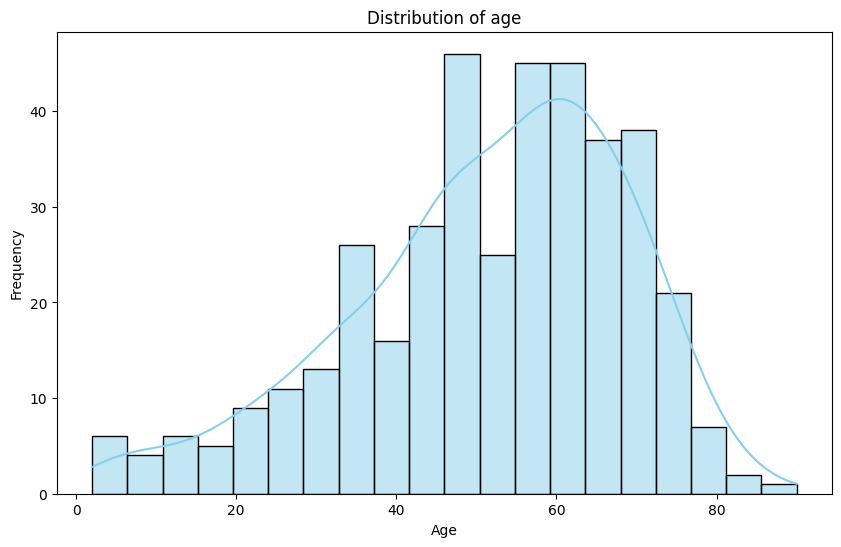

In [35]:
# Univariate Analysis>> One feature at a time

# dropna means drop null values

plt.figure(figsize = (10,6))
sns.histplot(df['age'].dropna(), kde = True, bins = 20,  color= 'skyblue')
plt.title('Distribution of age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [36]:
# insights>> Age column is left skewe data

In [37]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

###### Hypertension

In [38]:
df['hypertension'].value_counts

<bound method IndexOpsMixin.value_counts of 0      yes
1       no
2       no
3      yes
4       no
      ... 
395     no
396     no
397     no
398     no
399     no
Name: hypertension, Length: 400, dtype: object>

##### Detecting some different plots

<Axes: xlabel='hypertension', ylabel='count'>

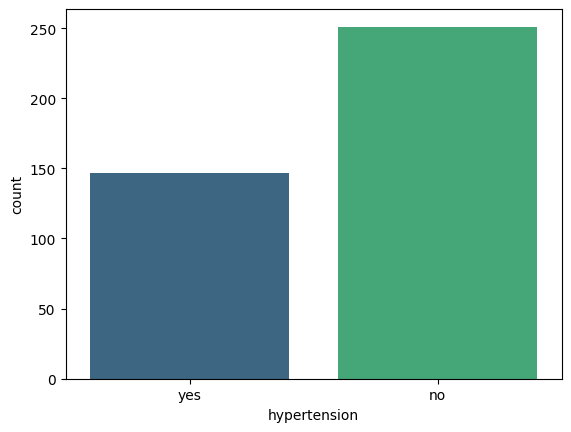

In [39]:
sns.countplot(x = 'hypertension', data= df, palette = 'viridis')

In [40]:
# Insights>> 150 has hypertension

In [41]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

###### Blood Urea

<Axes: xlabel='class', ylabel='blood_urea'>

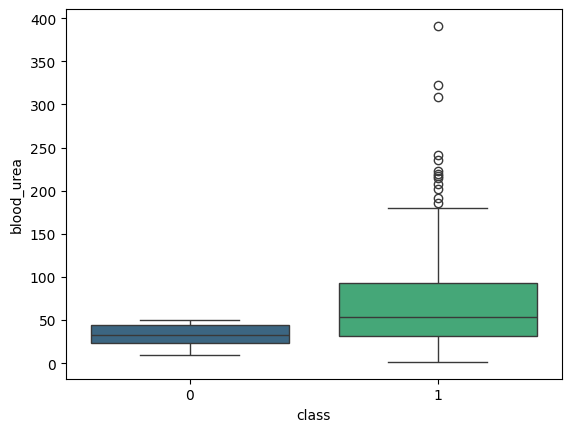

In [42]:
sns.boxplot(x= 'class', y= 'blood_urea', data= df, palette= 'viridis')
# 1 means having kidney disease

In [43]:
# Insights >> People with kidney disease has higher blood_urea with outlier, median value is also higher

<Axes: xlabel='class', ylabel='serum_creatinine'>

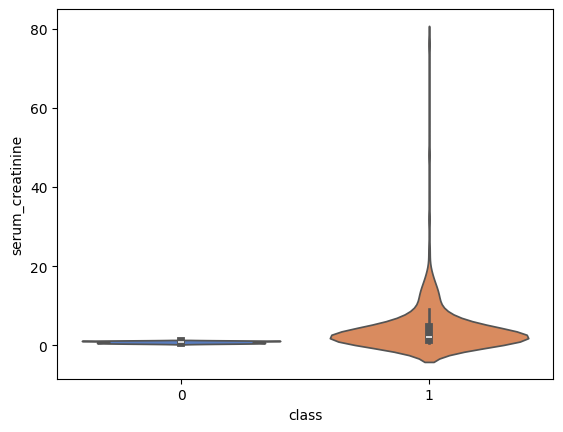

In [44]:
sns.violinplot(x= 'class', y= 'serum_creatinine', data= df, palette='muted')

###### Aanemia

<Axes: xlabel='aanemia', ylabel='count'>

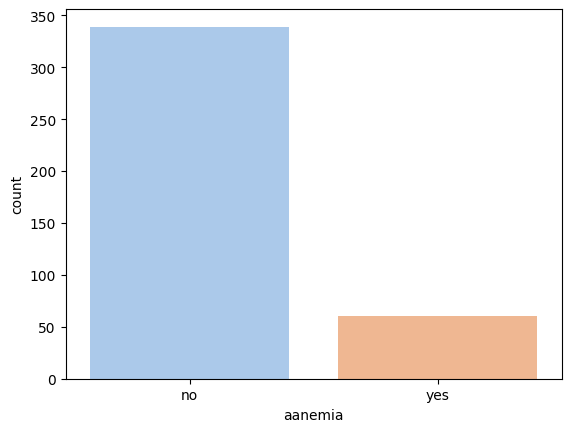

In [45]:
sns.countplot(x='aanemia', data=df, palette= 'pastel')

In [46]:
# insights>> Majority of people not suffering from aanemia

###### Appetite

<Axes: ylabel='count'>

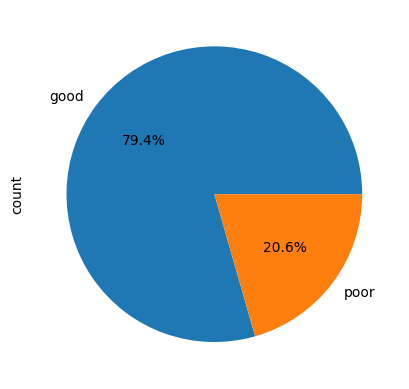

In [47]:
# opening in pie chart
df.appetite.value_counts().plot.pie(autopct = '%1.1f%%')
# autopct is used for numbers reflect on piechart

<Axes: ylabel='count'>

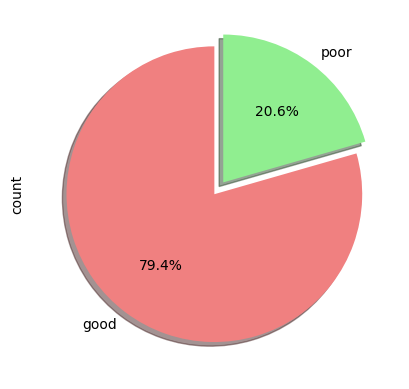

In [48]:
# Make it more beautiful, explode just seperate these colors
df.appetite.value_counts().plot.pie(autopct = '%1.1f%%', colors=['lightcoral', 'lightgreen'], explode= (0, 0.1),startangle =90, shadow= True)

In [49]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

###### pus cell clumps

In [50]:
df.pus_cell_clumps

0      notpresent
1      notpresent
2      notpresent
3         present
4      notpresent
          ...    
395    notpresent
396    notpresent
397    notpresent
398    notpresent
399    notpresent
Name: pus_cell_clumps, Length: 400, dtype: object

<Axes: xlabel='pus_cell_clumps', ylabel='count'>

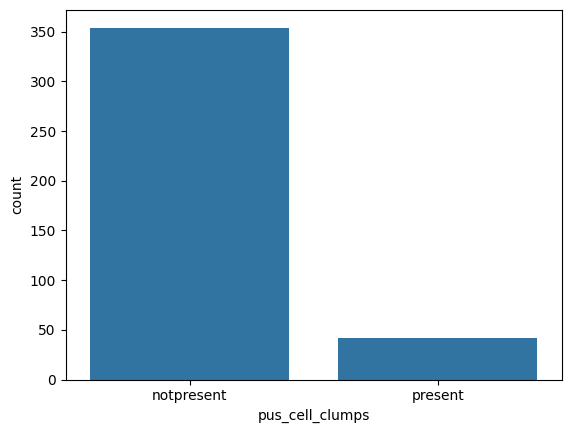

In [51]:
sns.countplot(x='pus_cell_clumps', data=df)

In [52]:
# insights>> Majority people doesn't have pus_cell_clumps

<Axes: xlabel='white_blood_cell_count', ylabel='Count'>

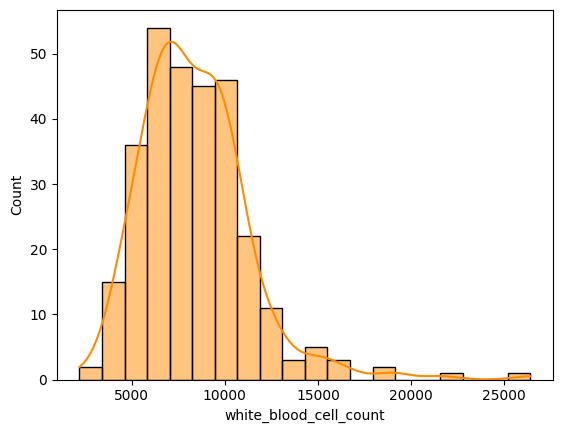

In [53]:
sns.histplot(df['white_blood_cell_count'].dropna(), bins=20, kde= True, color= 'darkorange')

###### Donut plot


In [54]:
# Donut plot>> donut chart or ring chart. It is essentially a pie chart with a hole in the center by specifying wedgeprops value
# It is used to display proportions

<Axes: ylabel='count'>

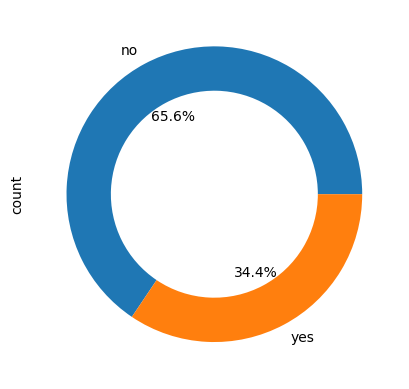

In [55]:
df['diabetes_mellitus'].value_counts().plot.pie(autopct = '%1.1f%%', wedgeprops = dict(width = 0.3))

###### cornary artery disease

<Axes: xlabel='coronary_artery_disease', ylabel='count'>

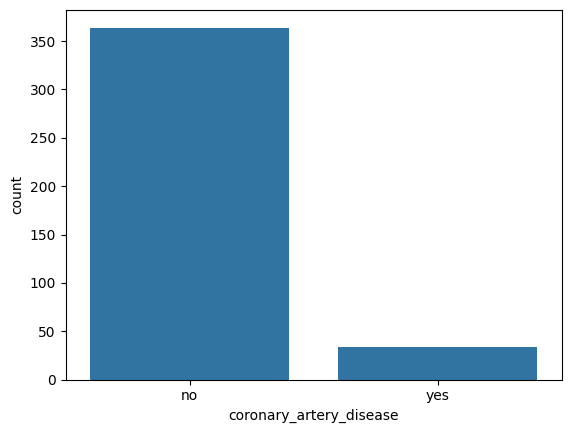

In [56]:
sns.countplot(x= 'coronary_artery_disease', data=df)

###### Peda edema

<Axes: xlabel='peda_edema', ylabel='count'>

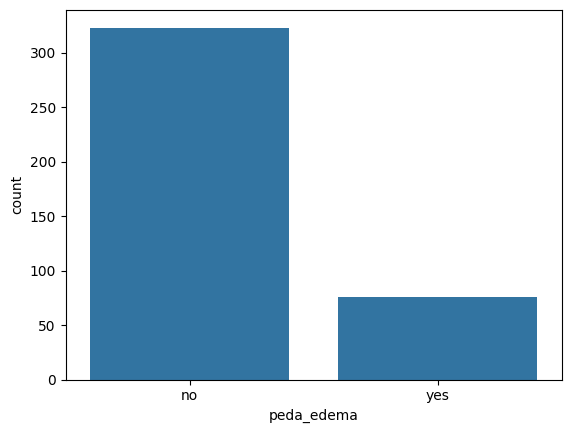

In [57]:
sns.countplot(x= 'peda_edema', data=df)

###### Bacteria

<Axes: xlabel='bacteria', ylabel='count'>

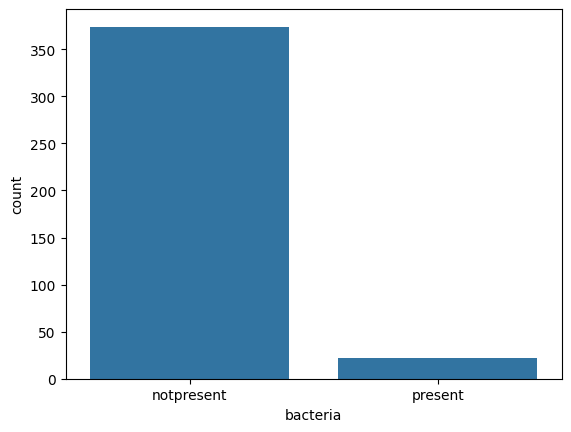

In [58]:
sns.countplot(x='bacteria', data= df)

#### Bivariate Analysis

In [59]:
# Bivariate Analysis >> Two feature at a time

<Axes: xlabel='age', ylabel='blood_pressure'>

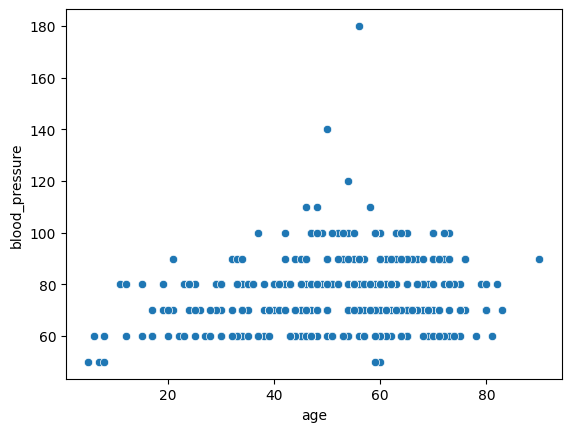

In [60]:
sns.scatterplot(x='age', y='blood_pressure', data=df)

In [61]:
# insights > As age is increasing BP also increasing

<Axes: xlabel='age', ylabel='blood_pressure'>

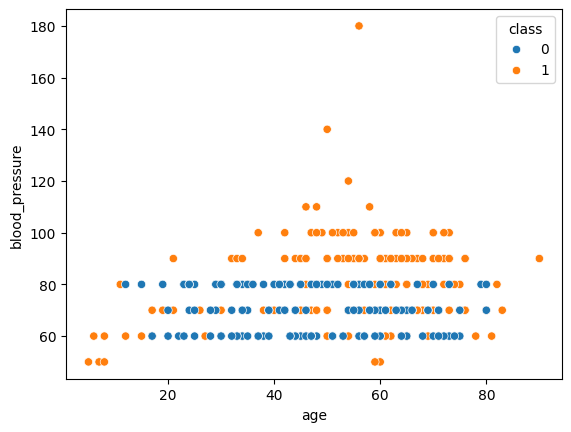

In [62]:
sns.scatterplot(x='age', y='blood_pressure', data=df, hue= 'class')
# class 0  means doesn't having, class 1 means having

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

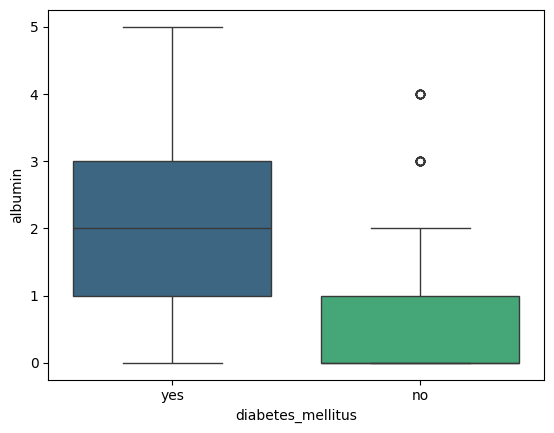

In [63]:
sns.boxplot(x= 'diabetes_mellitus', y= 'albumin', data=df, palette= 'viridis')

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

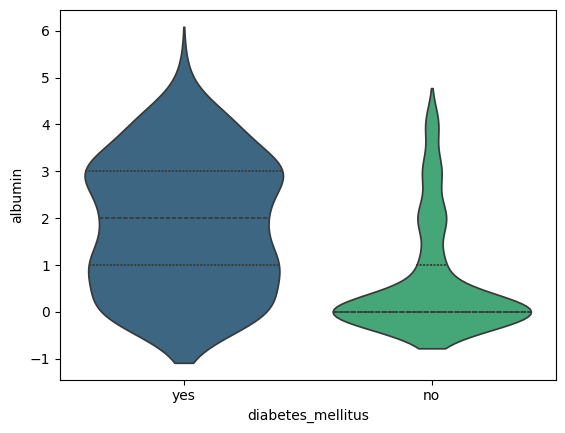

In [64]:
sns.violinplot(x= 'diabetes_mellitus', y= 'albumin', data=df,inner='quartile', palette= 'viridis')

In [65]:
# Stacked bar chart>> diabetes_mellitus and hypertension
pd.crosstab(df['diabetes_mellitus'], df['hypertension'])
# crosstab summerises the data


hypertension,no,yes
diabetes_mellitus,,
no,220,41
yes,31,106


<Axes: xlabel='diabetes_mellitus'>

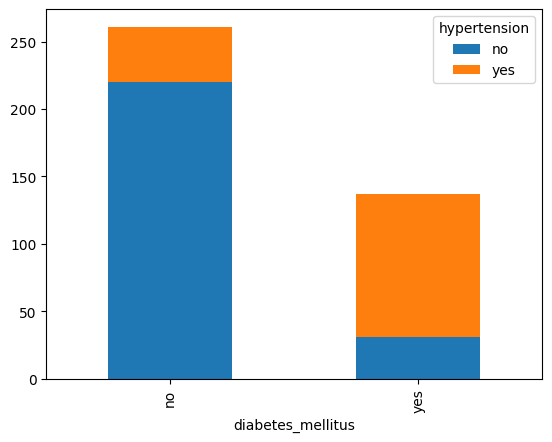

In [66]:
diabetes_hypertension = pd.crosstab(df['diabetes_mellitus'], df['hypertension'])
diabetes_hypertension.plot(kind= 'bar', stacked=True)

##### Multivariate Analysis

In [70]:
cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']
df[cols]

,age,blood_pressure,blood_glucose_random,serum_creatinine,class
0,48.0,80.0,121.0,1.2,1
1,7.0,50.0,NaN,0.8,1
2,62.0,80.0,423.0,1.8,1
3,48.0,70.0,117.0,3.8,1
4,51.0,80.0,106.0,1.4,1
...,...,...,...,...,...
395,55.0,80.0,140.0,0.5,0
396,42.0,70.0,75.0,1.2,0
397,12.0,80.0,100.0,0.6,0
398,17.0,60.0,114.0,1.0,0


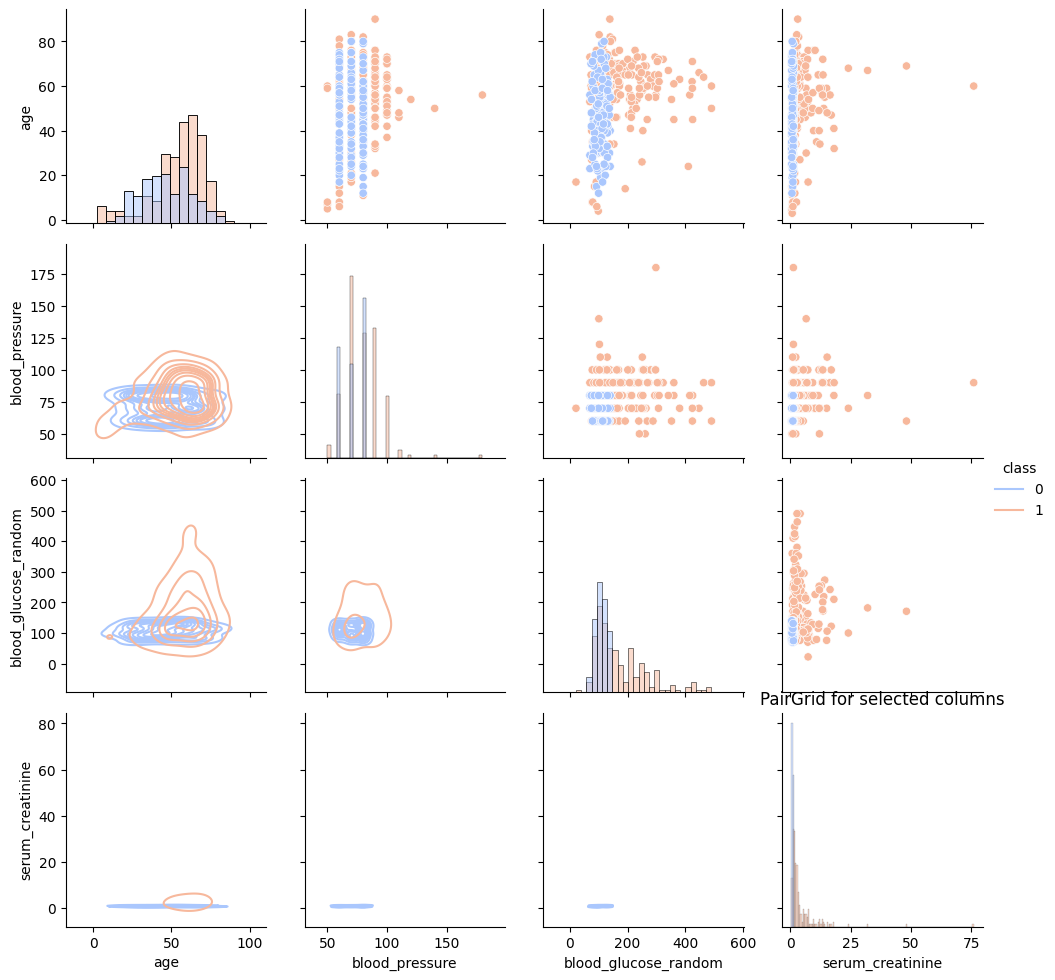

In [71]:
# Multivariate analysis
# customise pairplot
cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']
g = sns.PairGrid(df[cols], hue = 'class', palette= 'coolwarm')
g.map_upper(sns.scatterplot)   #anything which above the diagonal is upper side
g.map_lower(sns.kdeplot, cmap = 'Blues_d')  #anything which below the diagonal is lower side or kde plot
g.map_diag(sns.histplot) # and in diagonal this is a histogram
g.add_legend()
plt.title("PairGrid for selected columns")
plt.show()

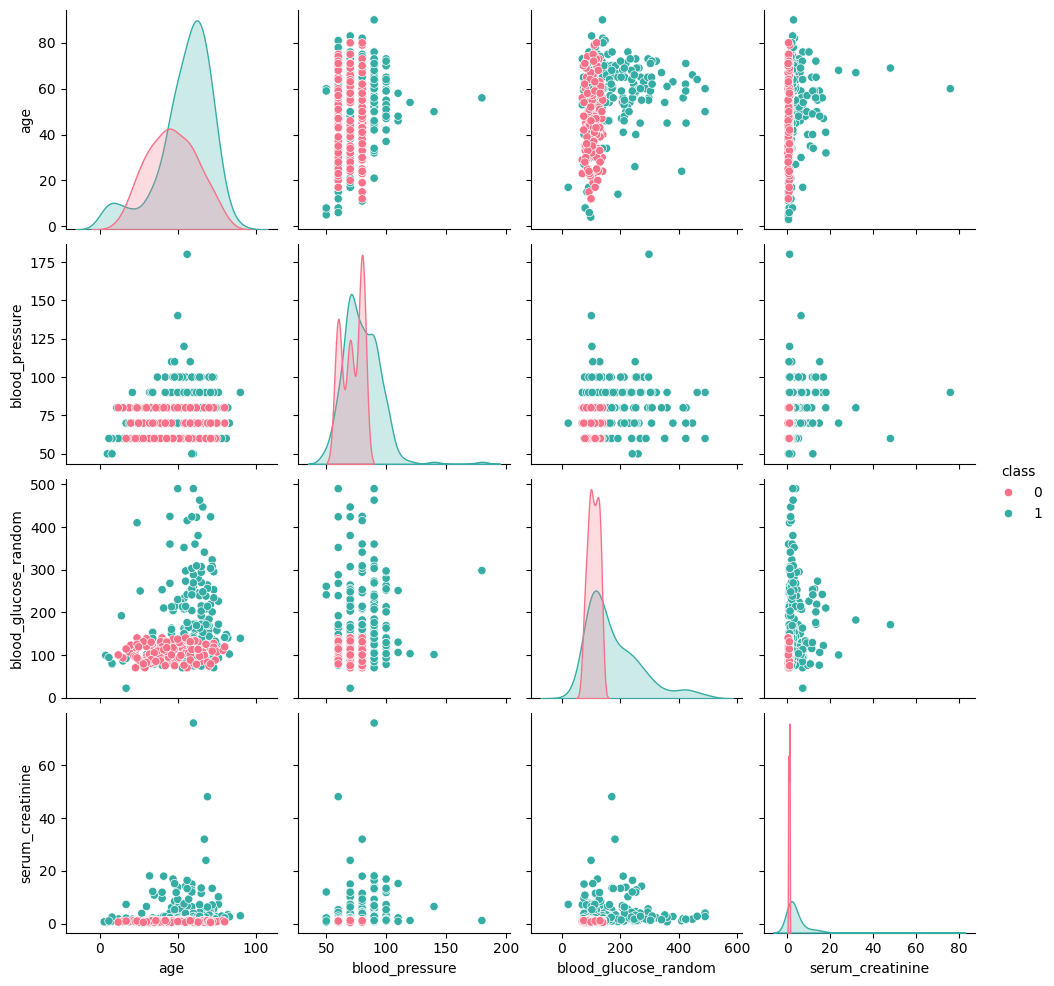

In [74]:
# Also can make a simple plot by just right
sns.pairplot(df[cols], hue = 'class', palette= 'husl')

###### Heat map

<Axes: >

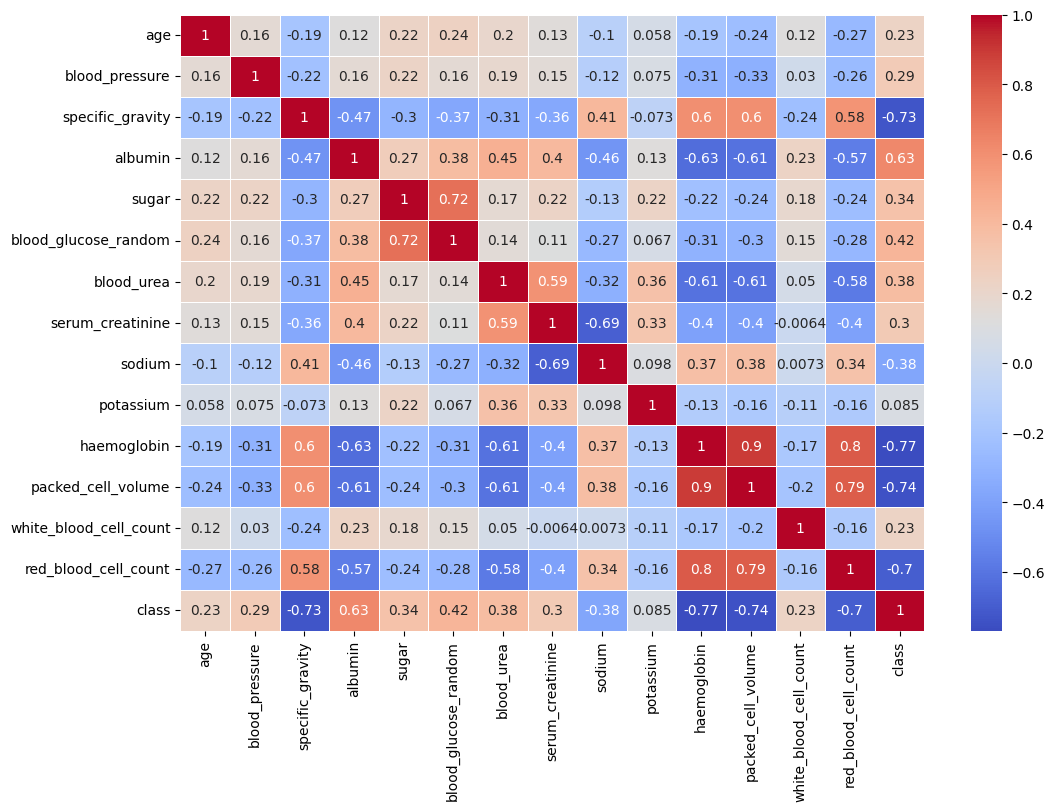

In [77]:
# Let's do some co-relation by using heatmap
corr = df.corr(numeric_only= True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap = 'coolwarm', linewidths= 0.5)

###### Swarm Plot

<Axes: xlabel='diabetes_mellitus', ylabel='age'>

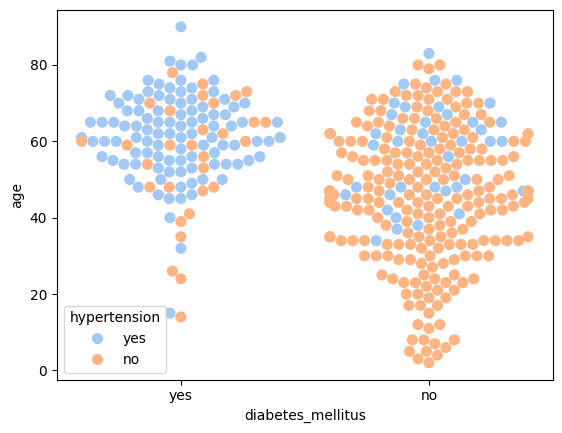

In [78]:
sns.swarmplot(x = 'diabetes_mellitus', y = 'age', hue= 'hypertension', data= df, palette= 'pastel', size= 8)

In [ ]:
# What is different between SwarmPlot and ScatterPlot?
# Swarm plot allows to see all the overlapping data as well
# In ScatterPlot if the values are overlaping then u will not be able to find it.

###### Interactive scatter plot

In [80]:
# Making a interactive scatter plot
fig = px.scatter(df, x= 'age', y= 'blood_pressure', color= 'class')
fig.show()

In [82]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [87]:
# other method called>> Hover Data
fig = px.scatter(df, x= 'age', y= 'blood_pressure', color= 'class', hover_data=['serum_creatinine', 'haemoglobin'], title= "Interactive ScatterPlot")
fig.show()

###### 3D plot

In [89]:
fig = px.scatter_3d(df, x='age', y='blood_pressure', z = 'serum_creatinine', color= 'class', title= "3D Scatter Plot")
fig.show()

###### Heatmap

In [94]:
# In plotly you can use two ways either Graph object or plotly express

import plotly.graph_objects as go
data_corr = df.corr(numeric_only= True)
fig2 = go.Figure(data = go.Heatmap(z = data_corr.values, x = data_corr.columns, y = data_corr.index))
fig2.show()


In [95]:
# Also make a different scatter plot with different column as well
fig = px.scatter_3d(df, x='age', y='blood_pressure', z = 'serum_creatinine', color= 'haemoglobin', title= "3D Scatter Plot")
fig.show()

In [96]:
df.isnull().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [97]:
cate_col
# if categorical column just replaced with mode

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [98]:
num_col
# and if numerical column, replace with mean and median

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [100]:
# Replace with median, mean>> for numerical columns
median_values = df[num_col].median()

In [101]:
median_values

age                         55.00
blood_pressure              80.00
specific_gravity             1.02
albumin                      0.00
sugar                        0.00
blood_glucose_random       121.00
blood_urea                  42.00
serum_creatinine             1.30
sodium                     138.00
potassium                    4.40
haemoglobin                 12.65
packed_cell_volume          40.00
white_blood_cell_count    8000.00
red_blood_cell_count         4.80
dtype: float64

In [102]:
df[num_col] = df[num_col].fillna(median_values)

In [103]:
df[num_col].isna().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [106]:
mode_values = df.mode().iloc[0]

In [114]:
df[cate_col] = df[cate_col].fillna(mode_values)
# inplace = True or just reassign the value ex:- df[cate_col]

In [115]:
df[cate_col].isna().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [116]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
aanemia                     object
class                        int64
dtype: object

In [118]:
# few columns are object columns>> convert object to numerical

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in cate_col:
    df[col] = label_encoder.fit_transform(df[col])

In [119]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [120]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [121]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells              int32
pus_cell                     int32
pus_cell_clumps              int32
bacteria                     int32
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                 int32
diabetes_mellitus            int32
coronary_artery_disease      int32
appetite                     int32
peda_edema                   int32
aanemia                      int32
class                        int64
dtype: object

In [122]:
x = df.drop('class', axis = 1)
y = df['class']